# Streamgauge network design for Brazil

This notebook demonstrates the hydrosensenet workflow on GloFAS data over Brazil:

1. Download GloFAS streamflow data via the CDS API
2. Download Brazil gauge locations (CAMELS-BR), watershed regions (ANA), and country boundary (GADM)
3. Clip to Brazil, build a time-by-cell matrix, split into train / test
4. Match existing gauges to the nearest valid grid cell, assign basins
5. Design an optimal sensor network using regional QR (one allocation per hydrographic region)
6. Compare the optimal network against the existing gauges
7. Visualize the per-cell ΔNNSE improvement

## Before running

1. Create an ECMWF account at <https://ewds.climate.copernicus.eu/>
2. Install dependencies: `pip install cdsapi cfgrib rioxarray`
3. Copy your API key from the profile page
4. Create `~/.cdsapirc` (or `C:\Users\<you>\.cdsapirc`) containing:

   ```
   url: https://ewds.climate.copernicus.eu/api
   key: PERSONAL-ACCESS-TOKEN
   ```

In [1]:
from pathlib import Path
import glob

import numpy as np
import pandas as pd
import geopandas as gpd

from hydrosensenet.data import (
    GloFASDataLoader,
    download_brazil_gauges, download_brazil_watersheds, download_country_boundary,
)
from hydrosensenet.data.loaders import load_streamflow_data, prepare_gauge_locations
from hydrosensenet.data.preprocessors import (
    clip_to_region, prepare_matrix, split_and_filter_data,
    match_gauges_to_grid, grid_to_point_gdf,
    assign_basins, count_gauges_per_basin,
)
from hydrosensenet.designer import SensorNetworkDesigner

In [2]:
# Configuration
name       = "brazil"
bounds     = [5.5, -74, -34, -34]      # CDS API: [North, West, South, East]
extent     = [-74, -34, -34, 5.5]      # clip_to_region: [west, east, south, north]
start_date = "2020-01-01"
end_date   = "2023-12-31"
YEARS      = list(range(2020, 2024))

OUTPUT_DIR = Path(f"./data/{name}")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Region:  {name}, bounds={bounds}")
print(f"Period:  {start_date} to {end_date}")
print(f"Output:  {OUTPUT_DIR}")

Region:  brazil, bounds=[5.5, -74, -34, -34]
Period:  2020-01-01 to 2023-12-31
Output:  data\brazil


## Step 1: Download GloFAS streamflow

Uses the Copernicus CDS API. Only downloads years that aren't already on disk.

In [3]:
loader = GloFASDataLoader()
loader.set_region(bounds=bounds, name=name)

# Skip years already on disk
missing = [y for y in YEARS
           if not (OUTPUT_DIR / f"{name}_streamflow_{y}.grib").exists()]

if missing:
    print(f"Missing years: {missing}")
    for year in missing:
        loader.download_streamflow(
            start_date=f"{year}-01-01",
            end_date=f"{year}-12-31",
            output_dir=OUTPUT_DIR,
            download_by="year",
        )
else:
    print("All years already downloaded.")

Region 'brazil': N=5.5, W=-74, S=-34, E=-34 (~1580.0 deg^2)
All years already downloaded.


## Step 2: Brazil gauge locations (CAMELS-BR)

Source: <https://zenodo.org/records/15025488>

In [4]:
gauge_path = download_brazil_gauges(
    output_dir=OUTPUT_DIR,
    zip_file="BRA_gauges.zip",
    gpkg_file="BRA_location_gauges.gpkg",
)

Already exists: data\brazil\BRA_location_gauges.gpkg


## Step 3: Brazil watershed boundaries (ANA)

Source: <https://metadados.snirh.gov.br>

In [5]:
basin_path = download_brazil_watersheds(
    output_dir=OUTPUT_DIR,
    zip_file="BRA_watersheds.zip",
    shp_file="BRA_watersheds.shp",
)

Already exists: data\brazil\BRA_watersheds.shp


## Step 4: Brazil country boundary (GADM)

Source: <https://gadm.org/download_country.html>

In [6]:
bnd_path = download_country_boundary(
    output_dir=OUTPUT_DIR,
    iso3="BRA",
)

Already exists: data\brazil\gadm41_BRA.shp


## Step 5: Load and preprocess

Load the GloFAS files, clip to the Brazil boundary, build the time-by-cell matrix, then split and filter.

In [7]:
GLOFAS_FILES = sorted(glob.glob(str(OUTPUT_DIR / f"{name}_streamflow_20*.grib")))

basin_gdf   = gpd.read_file(basin_path).to_crs("EPSG:4326")
brazil_poly = gpd.read_file(bnd_path).to_crs("EPSG:4326").dissolve().geometry.values[0]

gauge_gdf = prepare_gauge_locations(gauge_path)
print(f"Gauges: {gauge_gdf.shape[0]:,}")

Gauges: 4,025


In [8]:
glofas = load_streamflow_data(GLOFAS_FILES)
print(f"GloFAS:  {dict(glofas.sizes)}")

glofas_clipped = clip_to_region(glofas, brazil_poly, extent)
print(f"Clipped: {dict(glofas_clipped.sizes)}")

GloFAS:  {'time': 1461, 'latitude': 790, 'longitude': 800}
Clipped: {'time': 1461, 'latitude': 780, 'longitude': 783}


In [9]:
# (time x cells) matrix + a label list "(lat, lon)" for each cell
matrix, valid_lat_lon = prepare_matrix(glofas_clipped)
print(f"Matrix: {matrix.shape}")

Matrix: (1461, 283815)


In [10]:
# Train/test split, then drop cells with NaN/inf in the training set.
# mapping_df keeps track of which cells survived (needed downstream).
X_train, X_test, mapping_df = split_and_filter_data(
    matrix, valid_lat_lon, train_frac=0.7, verbose=True,
)

Split: train (1022, 283814), test (439, 283814)
Filter: kept 283,814 of 283,815 locations (100.0%)


## Step 6: Match gauges to the grid, assign basins

Each surviving grid cell becomes a Point in a GeoDataFrame, then we attach a basin label using `sjoin_nearest`. Existing gauges are snapped to their nearest cell.

In [11]:
# Surviving grid cells -> Point GeoDataFrame (col_pos is 0..n-1, aligned with X_train columns)
points_gdf = grid_to_point_gdf(mapping_df, verify=True)

# Attach basin info. assign_basins standardizes the output columns to
# 'basin_id' and 'basin_name' regardless of the shapefile's column names.
points_with_basin = assign_basins(
    points_gdf=points_gdf,
    basin_gdf=basin_gdf,
    basin_id_col="rhi_cd",
    basin_name_col="rhi_nm",
    basin_crs="EPSG:5880",   # SIRGAS 2000 / Brazil Polyconic — projected for accurate distances
)
points_with_basin[["col_pos", "lat", "lon", "basin_id", "basin_name"]].head()

,col_pos,lat,lon,basin_id,basin_name
0,0,5.225,-60.275,1.0,AMAZÔNICA
1,1,5.225,-60.225,1.0,AMAZÔNICA
2,2,5.225,-60.175,1.0,AMAZÔNICA
3,3,5.225,-60.125,1.0,AMAZÔNICA
4,4,5.175,-60.675,1.0,AMAZÔNICA


In [12]:
# Snap each existing gauge to its nearest valid grid cell.
# Pass the POST-filter labels so the returned indices line up with X_train columns.
filtered_labels = mapping_df.loc[mapping_df["is_valid"], "lat_lon"].tolist()
grid_lats = glofas_clipped.latitude.values
grid_lons = glofas_clipped.longitude.values

sensor_indices, gauge_gdf_matched = match_gauges_to_grid(
    gauge_gdf, grid_lats, grid_lons, filtered_labels,
)
print(f"Matched gauges: {len(sensor_indices):,} of {len(gauge_gdf):,}")

Matched 4006 of 4025 gauges to valid grid cells
Matched gauges: 4,006 of 4,025


In [13]:
# How many existing gauges fall in each hydrographic region?
# We'll use these counts as the per-region sensor budget so the comparison is fair.
gauge_counts = count_gauges_per_basin(
    gauge_gdf=gauge_gdf_matched,
    basin_gdf=basin_gdf,
    basin_id_col="rhi_cd",
    basin_name_col="rhi_nm",
    basin_crs="EPSG:5880",
)
gauge_counts

Assigned 4006 gauges to 12 basins


{'AMAZÔNICA': 396,
 'ATLÂNTICO LESTE': 263,
 'ATLÂNTICO NORDESTE OCIDENTAL': 68,
 'ATLÂNTICO NORDESTE ORIENTAL': 219,
 'ATLÂNTICO SUDESTE': 581,
 'ATLÂNTICO SUL': 254,
 'PARAGUAI': 120,
 'PARANÁ': 1256,
 'PARNAÍBA': 64,
 'SÃO FRANCISCO': 395,
 'TOCANTINS-ARAGUAIA': 206,
 'URUGUAI': 184}

## Step 7: Design optimal sensor network

Regional QR: pick the same number of sensors per hydrographic region as the existing gauge distribution, so the comparison against the existing network is apples-to-apples.

In [14]:
designer = SensorNetworkDesigner(
    X_train=X_train,
    X_test=X_test,
    locations=points_with_basin,
    location_labels=filtered_labels,
)
print(f"Designer: {len(designer.locations):,} locations")

Designer: 283,814 locations


In [15]:
optimal_result = designer.design_network(
    region_column="basin_name",
    sensors_per_region=gauge_counts,
    evaluate=True,
    verbose=True
)
optimal_result.print_summary()


Designing sensor network: 4006 sensors, regional selection
  Data: train (1022, 283814), test (439, 283814)

Selected 4006 optimal sensor locations
  Selection done in 110.7s (4006 sensors)
      - Extracting data for 4006 selected sensors...
      - Computing Gram matrix (4006 × 4006)...
      - Solving linear system for reconstruction...
      ⚠ Warning: Gram matrix is rank-deficient (rank=1405, expected=4006)
        This suggests some sensors provide redundant information.
      - Reconstructing full field (439 × 283,814)...
      - Calculating error metrics...
  Evaluation done in 75.3s (relative error: 0.1518)

Sensor network design
  Sensors selected: 4006
  Regional allocation (basin_name):
    AMAZÔNICA: 396
    ATLÂNTICO LESTE: 263
    ATLÂNTICO NORDESTE OCIDENTAL: 68
    ATLÂNTICO NORDESTE ORIENTAL: 219
    ATLÂNTICO SUDESTE: 581
    ATLÂNTICO SUL: 254
    PARAGUAI: 120
    PARANÁ: 1256
    PARNAÍBA: 64
    SÃO FRANCISCO: 395
    TOCANTINS-ARAGUAIA: 206
    URUGUAI: 184
  I

## Step 8: Evaluate the existing gauge network

Force the designer to use the existing gauge positions (no QR is run). Same number of sensors → directly comparable performance metrics.

In [16]:
ex_result = designer.design_network(
    n_sensors=len(sensor_indices),
    existing_sensors=sensor_indices.tolist(),
    evaluate=True,
    verbose=True,
)
ex_result.print_summary()


Designing sensor network: 4006 sensors, global selection
  Data: train (1022, 283814), test (439, 283814)
  Using provided 4006 sensors (skipping QR)
  Selection done in 0.0s (4006 sensors)
      - Extracting data for 4006 selected sensors...
      - Computing Gram matrix (4006 × 4006)...
      - Solving linear system for reconstruction...
      ⚠ Warning: Gram matrix is rank-deficient (rank=1080, expected=4006)
        This suggests some sensors provide redundant information.
      - Reconstructing full field (439 × 283,814)...
      - Calculating error metrics...
  Evaluation done in 75.1s (relative error: 0.0984)

Sensor network design
  Sensors selected: 4006
  Indices: [np.int64(63370), np.int64(67333), np.int64(70111), np.int64(70111), np.int64(68041), np.int64(65339), np.int64(53950), np.int64(47266), np.int64(47269), np.int64(49694)] ...

  Performance (median across locations):
    NSE:  0.521
    NNSE: 0.676
    Relative error: 0.0984


## Step 9: Compare networks and visualize

`plot_comparison` auto-detects the data type from `self.locations.geometry`:

- **Point on a regular lat/lon grid** (GloFAS) → pcolormesh background
- **LineString** (USGS / NWM reaches) → colored flowlines
- **Scattered Points** → no background, just markers

If auto-detection picks wrong, pass `network_type='grid' | 'reaches' | 'points'` explicitly.

In [17]:
optimal_nnse = optimal_result.eval_results["nnse"]
ex_nnse      = ex_result.eval_results["nnse"]
improvement  = optimal_nnse - ex_nnse

print(f"Mean ΔNNSE:   {np.nanmean(improvement):.4f}")
print(f"Median ΔNNSE: {np.nanmedian(improvement):.4f}")
n_improved = (improvement > 0).sum()
print(f"Improved:     {n_improved:,} / {len(improvement):,} "
      f"({100 * n_improved / len(improvement):.1f}%)")

Mean ΔNNSE:   0.0155
Median ΔNNSE: -0.0006
Improved:     135,347 / 283,814 (47.7%)


(<Figure size 1600x1200 with 2 Axes>, <GeoAxes: >)

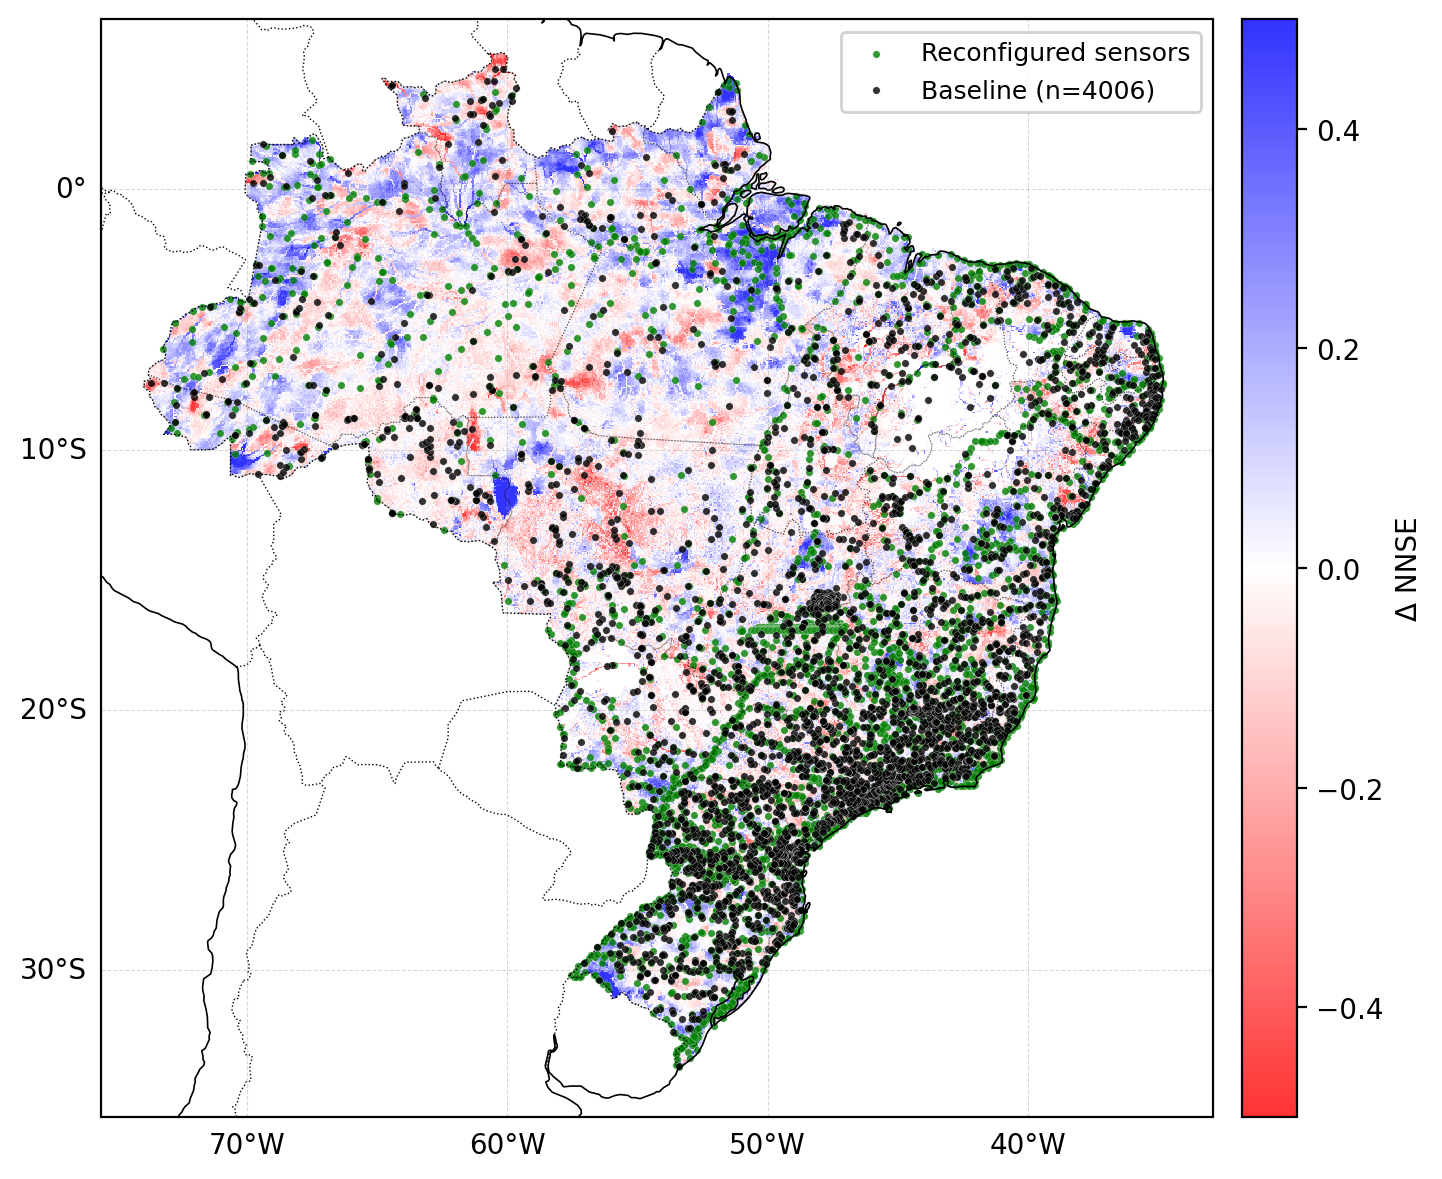

In [18]:
optimal_result.plot_comparison(ex_result, metric="nnse")